# 03 — Index Construction: AI Maturity Index (0–100)

Builds the composite index from the five dimensions (strategy, operations,
governance, technology, people; two indicators each) following the step
order of the OECD Handbook on Constructing Composite Indicators:

1. **Compose & select** — merge all indicator parquets of the active
   universe into one matrix, keep the ten index indicators plus the
   companion columns that carry each missing value's mechanism.
2. **Imputation (Step 3)** — analyse missingness by mechanism, impute
   structural zeros, leave coverage gaps marked, and estimate how much
   evidence each tone indicator actually rests on.
3. **Multivariate analysis (Step 4)** — correlation structure, principal
   components, internal consistency.
4. **Normalisation (Step 5)** — square-root transformation of the skewed
   indicators, then min-max scaling to [0, 1].
5. **Weighting & aggregation (Step 6)** — hierarchical equal weighting with
   per-firm reliability weights, linear composite on 0–100.
6. **Sensitivity analysis** — rank robustness across method variants.
7. **Firm typology** — cluster analysis on the final dimension scores.
8. **Outputs** — scores parquet + self-contained HTML ranking report.

Prerequisite: all five dimension notebooks in `02_feature_engineering`
have run for the same `UNIVERSE`.

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import sys
import webbrowser
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.index.aggregate import composite_index, dimension_scores, geometric_index
from src.index.compose import compose_index
from src.index.impute import (
    impute_sector_median,
    impute_structural_zeros,
    load_gics_sector,
    missingness_table,
)
from src.index import multivariate as mv
from src.index.normalize import minmax, rankscore, zscore
from src.index.reliability import estimate_tone_reliability, indicator_reliability
from src.index.report import build_index_report
from src.index.schema import ALL_QA_COLS, DIMENSIONS, INDEX_INDICATORS
from src.index.treat import distribution_table, sqrt_transform_skewed
from src.indicators.common.io import DATA_CLEAN
from src.indicators.common.universe import load_universe

UNIVERSE = "sp500"

pd.set_option("display.width", 160)
print(f"Universe: {UNIVERSE}")

Universe: sp500


## 1. Compose & select

Merge every indicator parquet of the universe into one matrix keyed on
`normalized_company_name`, then split it into the ten index indicators and
the companion columns (`*_reason`, `item_parsed`, `n_ai_sentences`) that
document why a value is missing. The full matrix is also written to
`data_clean/ai_maturity_index_<universe>.parquet` for reference.

In [2]:
matrix = compose_index(UNIVERSE, write=True)

_missing_dims = [d for d, cols in DIMENSIONS.items() if not all(c in matrix.columns for c in cols)]
if _missing_dims:
    raise RuntimeError(
        f"Indicator parquets missing for dimensions {_missing_dims} in universe {UNIVERSE!r}. "
        "Run notebooks/01_ingest_clean/nlp_features_setup.ipynb and "
        "structured_features_setup.ipynb, then the dimension notebooks in "
        "notebooks/02_feature_engineering (strategy/operations/governance, "
        "technology/people), first."
    )

assert matrix["normalized_company_name"].is_unique
# later steps line frames up by position rather than by key, so pin that down
assert matrix.index.equals(pd.RangeIndex(len(matrix))), "compose_index must return a fresh RangeIndex"
assert (matrix["normalized_company_name"].to_numpy()
        == load_universe(UNIVERSE)["normalized_company_name"].to_numpy()).all(), \
    "composed matrix no longer follows the universe row order"

qa_cols = [c for c in ALL_QA_COLS if c in matrix.columns]
print(f"{len(matrix)} firms x {len(INDEX_INDICATORS)} index indicators "
      f"(+{len(qa_cols)} QA columns)")
matrix[INDEX_INDICATORS].dtypes

500 firms x 10 index indicators (+10 QA columns)


strategy__ai_sentence_share         float64
strategy__net_tone                  float64
operations__ai_sentence_share       float64
operations__net_tone                float64
governance__ai_sentence_share       float64
governance__fls_score               float64
technology__ai_publication_share    float64
technology__ai_patent_share         float64
people__tech_team1_worker_share     float64
people__ai_worker_share             float64
dtype: object

## 2. Missing-data analysis and imputation (OECD Step 3)

Every missing value carries its mechanism, so the MCAR/MAR/NMAR
classification is grounded rather than assumed:

- **`zero_denominator`** — structural, NMAR modelled explicitly: the firm
  is matched but has zero total publications/patents, so its AI share
  cannot be positive. **Imputed as 0** and flagged.
- **`no_ai_sentences`** — structural: a parsed Item with no AI text has no
  defined tone. Left NaN; section 5 lets the dimension rest on the share
  alone at reduced weight rather than double-penalising or synthetically
  filling it.
- **`unmatched` / `item_unparsed` / `no_filing`** — coverage-driven
  (≈ MAR, conditional on source coverage and filing structure). Left NaN:
  imputing both indicators of a dimension from other firms would make that
  dimension fully synthetic (Dempster & Rubin's "dangerous" case). Firms
  where a whole dimension is empty get no composite (transparent
  exclusion, reported); a sector-median imputation runs as a sensitivity
  scenario in section 6.

No case deletion: all firms stay in the output.

In [3]:
miss_before = missingness_table(matrix)
print("=== Missingness by mechanism (before imputation) ===")
print(miss_before.to_string())

imputed, impute_flags = impute_structural_zeros(matrix)
n_imputed_per_firm = impute_flags.sum(axis=1)

miss_after = missingness_table(imputed)
print("\n=== After structural-zero imputation ===")
print(miss_after[["n_defined", "pct_missing"]].to_string())
print(f"\nimputed values: {int(impute_flags.values.sum())} across "
      f"{int((n_imputed_per_firm > 0).sum())} firms")

=== Missingness by mechanism (before imputation) ===
                                  n_defined  pct_missing  zero_denominator  unmatched  no_ai_sentences  item_unparsed  no_filing
indicator                                                                                                                       
strategy__ai_sentence_share             483        0.034                 0          0                0             10          7
strategy__net_tone                      275        0.450                 0          0              208             10          7
operations__ai_sentence_share           455        0.090                 0          0                0             38          7
operations__net_tone                    154        0.692                 0          0              301             38          7
governance__ai_sentence_share           481        0.038                 0          0                0             12          7
governance__fls_score                   458 

### 2.2 Measurement reliability of the tone indicators

A firm's tone is the mean of FinBERT scores over its AI sentences in one
Item, so it is a sample estimate: some firms have a single qualifying
sentence, others fifty. Treating both as equally precise would let a coin
flip on one sentence move a dimension as much as a well-evidenced average.

The standard correction is the variance-components (empirical Bayes)
result. Writing sentence *j* of firm *i* as `y_ij ~ (theta_i, sigma^2)`
with genuine between-firm spread `theta_i ~ (mu, tau^2)`, a firm mean based
on `n` sentences carries reliability

$$\lambda = \frac{n}{n+k}, \qquad k = \frac{\sigma^2}{\tau^2}$$

so **k is estimated, not chosen** — it is the ratio of within-firm to
between-firm variance, both identified from the cached sentence scores by a
one-way random-effects model. The intraclass correlation
`ICC = tau^2 / (tau^2 + sigma^2)` states the same thing per sentence: how
much a single sentence says about the firm rather than about which sentence
happened to be sampled. A method-of-moments estimate is reported alongside
as an independent check.

The share indicators keep reliability 1 throughout: a share is a complete
count over the Item, not an estimate from a sample of its sentences.

In [4]:
tone_reliability = estimate_tone_reliability(UNIVERSE)
print("=== Variance components of the sentence-level tone scores ===")
print(tone_reliability[["n_sentences", "n_firms", "median_n", "sigma2", "tau2",
                        "k", "icc", "k_moments_check"]].round(4).to_string())

K_BY_DIM = tone_reliability["k"].to_dict()
print("\nreliability of a firm tone at selected sentence counts:")
for _dim, _k in K_BY_DIM.items():
    print(f"  {_dim:11s} k={_k:7.2f}  "
          + "  ".join(f"n={n}:{n / (n + _k):.2f}" for n in (1, 2, 5, 10, 25, 50)))

# built on the imputed frame: a structurally imputed zero is an observed
# value and must keep full weight rather than read as missing
reliability = indicator_reliability(imputed, K_BY_DIM)
reliability.index = imputed["normalized_company_name"]
assert reliability.to_numpy().min() >= 0 and reliability.to_numpy().max() <= 1

print("\nThe governance tone is the outlier: nearly all of the spread between")
print("firms is sampling noise, so even a firm with the median number of")
print("sentences carries little weight. Read that as a property of the object")
print("rather than a defect of the index — prospective phrasing in AI risk")
print("factors is largely standard legal drafting, so firms genuinely differ")
print("little on it. Because the index is formative, an indicator that")
print("discriminates weakly simply contributes little; it is not evidence that")
print("the dimension is mismeasured, and the weighting handles it without any")
print("need to redefine the construct to chase a higher reliability.")

=== Variance components of the sentence-level tone scores ===
            n_sentences  n_firms  median_n  sigma2    tau2         k     icc  k_moments_check
dimension                                                                                    
strategy           2433      275       4.0  0.2179  0.0566    3.8533  0.2060           2.2234
operations          572      154       2.0  0.3143  0.1171    2.6841  0.2714           1.9524
governance         5199      458       9.0  0.1788  0.0017  105.9316  0.0094         207.9563

reliability of a firm tone at selected sentence counts:
  strategy    k=   3.85  n=1:0.21  n=2:0.34  n=5:0.56  n=10:0.72  n=25:0.87  n=50:0.93
  operations  k=   2.68  n=1:0.27  n=2:0.43  n=5:0.65  n=10:0.79  n=25:0.90  n=50:0.95
  governance  k= 105.93  n=1:0.01  n=2:0.02  n=5:0.05  n=10:0.09  n=25:0.19  n=50:0.32

The governance tone is the outlier: nearly all of the spread between
firms is sampling noise, so even a firm with the median number of
sentences carr

## 3. Multivariate analysis (OECD Step 4)

Runs on the imputed indicators, before any transformation or scaling, as in
the handbook's step order. Each method standardises internally where it has
to — that is intrinsic to PCA and k-means, not a normalisation choice — so
the provisional dimension scores used here are built from z-standardised
indicators. Section 4 verifies explicitly that these structural conclusions
survive the transformation applied there.

**The index is a formative construct.** The two indicators of a dimension
are distinct facets by design — the extensive margin (how much a firm
discloses about AI) and the intensive margin (how it frames that
disclosure), following the Babina et al. decomposition — not
interchangeable manifestations of one latent trait. Low within-dimension
correlation is therefore an expected property of the design, not a
reliability defect, and reflective-model tools are not the right lens
(see 3.5).

Three questions are asked here:
- **3.1 Correlation structure** — does averaging each dimension's pair hold
  up, and is any pair so collinear that equal weighting would double count?
- **3.2 Principal components** — do the five dimensions share one dominant
  latent component, and do they contribute comparably (which would give the
  equal weighting empirical backing rather than leaving it a convenience
  assumption)?
- **3.3 Internal consistency** — how coherent is the set, and which
  dimension sits furthest from the rest?

The handbook's fourth tool, cluster analysis, is reported in section 7
instead. All three methods above are scale-invariant — min-max is affine,
so correlations and standardised PCA are untouched by it (verified to
1e-15) — which is what lets them sit ahead of the normalisation without
consequence. k-means is not: it works on Euclidean distances, so its
result depends on the scaling, and clustering the provisional scores here
would label firms by a different object than the published index. On this
data the two clusterings agree on only 66% of firms (adjusted Rand index
0.35), so the typology is computed where it belongs, on the final
dimension scores.

=== 3.1 Within-dimension correlation ===
                r  n_pairwise
dimension                    
strategy    0.061         275
operations  0.102         154
governance  0.010         458
technology  0.197         458
people      0.674         458

Low values are expected for a formative construct: the extensive and
intensive margins of one dimension measure different things by design.


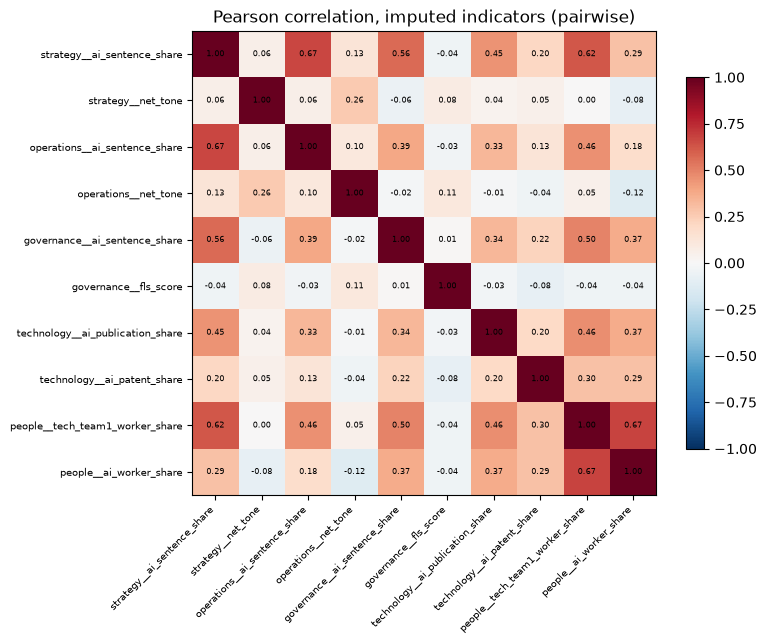

=== Double-counting check (|r| > 0.9) ===
none — equal weighting introduces no double counting


In [5]:
# provisional dimension scores for the methods that need a common scale;
# z-standardisation is what PCA and k-means require anyway
_prov = zscore(imputed, columns=INDEX_INDICATORS)
dim_scores_prov, _ = dimension_scores(
    _prov.set_index("normalized_company_name")[INDEX_INDICATORS], reliability=reliability
)

print("=== 3.1 Within-dimension correlation ===")
print(mv.within_dimension_correlations(imputed)[["r", "n_pairwise"]].round(3).to_string())
print("\nLow values are expected for a formative construct: the extensive and")
print("intensive margins of one dimension measure different things by design.")

# pairwise, so the tone indicators' missingness does not shrink the analysis
# to the AI-heavy subsample
corr = mv.correlation_matrix(imputed, INDEX_INDICATORS)

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=7)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)
fig.colorbar(im, shrink=0.8)
ax.set_title("Pearson correlation, imputed indicators (pairwise)")
fig.tight_layout()
plt.show()

print("=== Double-counting check (|r| > 0.9) ===")
_flagged = mv.double_counting_check(corr)
print(_flagged.to_string(index=False) if len(_flagged) else "none — equal weighting introduces no double counting")
assert len(_flagged) == 0, "collinear indicator pair needs a weighting decision"

In [6]:
# 3.2 PCA. Primary analysis at dimension level: every eligible firm has all
# five dimension scores by construction, whereas complete cases across all ten
# indicators cover only a fraction of the universe and are selected towards
# AI-heavy filers.
print("=== 3.2 PCA prerequisites (dimension level) ===")
_tests = mv.kmo_bartlett(dim_scores_prov)
print(f"  KMO sampling adequacy: {_tests['kmo']:.3f}  (n complete = {_tests['n_complete']})")
print(f"  Bartlett sphericity:   chi2 = {_tests['bartlett_chi2']:.1f}, "
      f"df = {_tests['bartlett_dof']}, p = {_tests['bartlett_p']:.2e}")

pca_variance, pca_loadings, _n = mv.pca_report(dim_scores_prov)
print(f"\n=== PCA on the 5 dimension scores (n = {_n}) ===")
print(pca_variance.round(3).to_string())
print("\nloadings:")
print(pca_loadings.round(3).to_string())
print(f"\ncomponents with eigenvalue > 1 (Kaiser): {int((pca_variance['eigenvalue'] > 1).sum())}")
assert (pca_loadings["PC1"] > 0).all(), "PC1 loadings must share one sign to read as a maturity axis"
print(f"PC1 loading spread: {pca_loadings['PC1'].min():.3f} .. {pca_loadings['PC1'].max():.3f} "
      "— comparable contributions support the equal weighting applied in section 5")

_var_i, _load_i, _n_i = mv.pca_report(imputed, INDEX_INDICATORS)
print(f"\n=== Robustness: PCA on the 10 indicators (n = {_n_i} complete cases) ===")
print(_var_i.head(4).round(3).to_string())
print(f"Caveat: {_n_i} of {len(imputed)} firms are complete across all ten indicators, and")
print("that subset is selected towards firms with enough AI text to yield a tone")
print("score. Treat as indicative only; the dimension-level PCA above is the")
print("structural evidence.")

=== 3.2 PCA prerequisites (dimension level) ===


  KMO sampling adequacy: 0.763  (n complete = 405)
  Bartlett sphericity:   chi2 = 650.9, df = 10, p = 2.12e-133

=== PCA on the 5 dimension scores (n = 405) ===
     eigenvalue  explained_variance_ratio  cumulative
PC1       2.790                     0.557       0.557
PC2       0.831                     0.166       0.722
PC3       0.628                     0.125       0.848
PC4       0.473                     0.094       0.942
PC5       0.291                     0.058       1.000

loadings:
              PC1    PC2    PC3
strategy    0.512  0.302 -0.145
operations  0.436  0.614 -0.311
governance  0.433  0.022  0.801
technology  0.405 -0.575 -0.474
people      0.444 -0.448  0.124

components with eigenvalue > 1 (Kaiser): 1
PC1 loading spread: 0.405 .. 0.512 — comparable contributions support the equal weighting applied in section 5

=== Robustness: PCA on the 10 indicators (n = 106 complete cases) ===
     eigenvalue  explained_variance_ratio  cumulative
PC1       3.591                

In [7]:
# 3.3 internal consistency, standardized (scale-free) form
print("=== 3.3 Internal consistency ===")
alpha_std = mv.cronbach_alpha(dim_scores_prov)
print(f"Cronbach's alpha (standardized, 5 dimension scores): {alpha_std:.3f}")
print("\nalpha if a dimension is left out:")
print(mv.alpha_if_deleted(dim_scores_prov).round(3).to_string())
print("\nA dimension whose removal raises alpha is the one furthest from the rest.")
print("For a formative index that is a structural observation, not grounds for")
print("dropping a theoretically required dimension.")

=== 3.3 Internal consistency ===


Cronbach's alpha (standardized, 5 dimension scores): 0.798

alpha if a dimension is left out:
strategy      0.711
operations    0.768
governance    0.767
technology    0.783
people        0.760

A dimension whose removal raises alpha is the one furthest from the rest.
For a formative index that is a structural observation, not grounds for
dropping a theoretically required dimension.


### 3.5 On factor analysis (OECD 4.2)

Factor analysis was considered and deliberately not used. It models
indicators as reflective manifestations of a latent variable, which is the
opposite of how this index is built: with within-dimension correlations as
low as those in 3.1, the reflective model is misspecified for these data.
Exploratory factor analysis would in practice reproduce what the PCA above
already shows, and confirmatory factor analysis — the tool that could
genuinely test the five-dimension structure — needs the complete-case
sample that section 3.2 shows we do not have. The handbook's main use of
factor analysis is deriving weights; this index weights dimensions equally
by design, a choice the near-uniform PC1 loadings now support empirically.

## 4. Normalisation (OECD Step 5)

Two stages. **First the transformation**: the shares are strongly
right-skewed with a large exact-zero mass (many firms have zero AI patents,
zero AI publications, ...), so the JRC screening rule (|skew| > 2 and
excess kurtosis > 3.5) selects the indicators that need treating.
Upper-percentile winsorization was tried first but left most violating
indicators still over the thresholds — capping the tail barely moves
skew/kurtosis when that much of the distribution sits at the floor. A
**square-root transform** resolves every violation instead: `sqrt(0) = 0`
is well defined (no epsilon-at-zero problem like `log`), and it is
monotonic, so the within-indicator ranking is unaffected.

**Then the scaling**: min-max to [0, 1], which maps directly onto the 0–100
target scale and, after the transformation, is no longer driven by the
extreme tail. The reference range is deliberately the whole universe, not
just the ranked firms, so an indicator's maximum may be set by a firm that
never receives a composite. Rank normalisation serves as a shape-free
sensitivity variant in section 6; a z-score variant is not tested
separately because it is affine to min-max and would produce an identical
ranking. Missing values stay missing — the weighting rule in section 5
builds on exactly those NaNs.

Because the transformation is non-linear it does shift correlations, so the
last cell re-runs the section-3 headline statistics on the transformed data
to confirm the structural conclusions do not depend on it.

In [8]:
print("=== Distributions after imputation ===")
print(distribution_table(imputed, INDEX_INDICATORS).round(3).to_string())

treated, treat_report = sqrt_transform_skewed(imputed, INDEX_INDICATORS)
print("\n=== Square-root transform (JRC rule) ===")
print(treat_report.round(3).to_string())

_still_violating = distribution_table(treated, INDEX_INDICATORS)["needs_treatment"]
assert not _still_violating.any(), (
    f"still JRC-violating after sqrt transform: {_still_violating[_still_violating].index.tolist()}"
)
print("\nall 10 indicators pass the JRC rule after treatment")

norm = minmax(treated, columns=INDEX_INDICATORS)[
    ["normalized_company_name"] + INDEX_INDICATORS
]
_vals = norm[INDEX_INDICATORS]
assert float(_vals.min().min()) >= 0 and float(_vals.max().max()) <= 1
print("normalized to [0, 1]; NaN preserved:",
      int(_vals.isna().sum().sum()), "missing cells")

=== Distributions after imputation ===
                                    n   skew  kurtosis  needs_treatment    min    p50   p975    max
indicator                                                                                          
strategy__ai_sentence_share       483  3.396    13.618             True  0.000  0.004  0.132  0.244
strategy__net_tone                275 -0.719     0.645            False -0.999  0.498  1.000  1.000
operations__ai_sentence_share     455  3.725    15.547             True  0.000  0.000  0.036  0.066
operations__net_tone              154 -1.115     0.456            False -1.000  0.633  1.000  1.000
governance__ai_sentence_share     481  1.503     3.243            False  0.000  0.023  0.085  0.147
governance__fls_score             458 -0.691     1.342            False  0.012  0.658  0.983  0.990
technology__ai_publication_share  458  3.016    10.652             True  0.000  0.019  0.544  1.000
technology__ai_patent_share       458  3.062    11.193       

In [9]:
# do the section-3 conclusions depend on the transformation applied above?
_prov_t = zscore(treated, columns=INDEX_INDICATORS)
_ds_t, _ = dimension_scores(
    _prov_t.set_index("normalized_company_name")[INDEX_INDICATORS], reliability=reliability
)
_var_t, _load_t, _ = mv.pca_report(_ds_t)
_corr_t = mv.correlation_matrix(treated, INDEX_INDICATORS)

print("=== Structural conclusions before vs after the transformation ===")
print(f"  PC1 explained variance : {pca_variance['explained_variance_ratio'].iloc[0]:.3f}"
      f"  ->  {_var_t['explained_variance_ratio'].iloc[0]:.3f}")
print(f"  components eigenvalue>1: {int((pca_variance['eigenvalue'] > 1).sum())}"
      f"      ->  {int((_var_t['eigenvalue'] > 1).sum())}")
print(f"  PC1 loadings all positive: {bool((pca_loadings['PC1'] > 0).all())}"
      f"   ->  {bool((_load_t['PC1'] > 0).all())}")
print(f"  Cronbach's alpha (std) : {alpha_std:.3f}"
      f"      ->  {mv.cronbach_alpha(_ds_t):.3f}")
print(f"  indicator pairs |r|>0.9: {len(mv.double_counting_check(corr))}"
      f"          ->  {len(mv.double_counting_check(_corr_t))}")
print("\nSame structure either way: one dominant component with comparable")
print("positive loadings, acceptable internal consistency, no double counting.")

=== Structural conclusions before vs after the transformation ===
  PC1 explained variance : 0.557  ->  0.570
  components eigenvalue>1: 1      ->  1
  PC1 loadings all positive: True   ->  True
  Cronbach's alpha (std) : 0.798      ->  0.811
  indicator pairs |r|>0.9: 0          ->  0

Same structure either way: one dominant component with comparable
positive loadings, acceptable internal consistency, no double counting.


## 5. Weighting and aggregation (OECD Step 6)

Two levels, and a "weight" could enter at either — but they answer
different questions and are treated differently on purpose.

**Within a dimension** the question is one of *estimation*: how best to read
this dimension off whatever indicators this firm has. The per-indicator
reliability from section 2.2 applies:

$$\text{dimension score} = \frac{\sum_j r_j x_j}{\sum_j r_j},
\qquad \text{coverage} = \frac{\sum_j r_j}{2}$$

**Across dimensions** the question is one of *definition*: how much does
this facet matter for AI maturity. The framework says all five matter
equally, so every observed dimension is weighted 1 and only an unobserved
one gets 0 — which under the availability rule removes the firm entirely.
`coverage` is reported as a data-quality diagnostic but does **not** weight
the composite. Letting it do so would make an unintended value judgement
("dimensions we happened to measure better matter more"), would contradict
the formative framing of section 3, and would treat an observed zero as if
it were partly unknown. On this data that choice is not cosmetic: coverage
weighting hands technology and people 53% of the index instead of 40%,
because they are the two dimensions whose indicators are never missing.
Section 6 keeps it as a sensitivity spec.

**What happens when a firm has no AI sentence at all.** Its tone is
undefined, so `r = 0` and the tone leaves the average: the denominator is
1, not 2, and the dimension score equals the share — which is itself a
measured zero, not an imputed one. Nothing is invented, and nothing is
counted twice: the absence is registered once, through the extensive
margin. In this data a missing tone and a zero share are the same firms
(208 in strategy, 301 in operations, 23 in governance), so the two never
come apart, and under equal weighting the composite is invariant to whether
one calls the tone excluded or zero.

Aggregation is **linear** (fully compensatory): a deficit in one dimension
can be offset by strength in another, which matches an economic maturity
measure whose dimensions are substitutable signals of the same construct.
The geometric variant (lower compensability at the low end) runs as a
sensitivity spec in section 6.

The 0–100 range is the **theoretical** span of the scale, not an achieved
one: reaching 100 would require topping every indicator in the universe. A
firm at exactly 0 scored the sample minimum on every indicator it has —
a measured absence of any AI signal, not a missing value, and the report
keeps the two apart.

In [10]:
scores, coverage = dimension_scores(
    norm.set_index("normalized_company_name")[INDEX_INDICATORS], reliability=reliability
)
# equal importance: an observed dimension counts 1, an unobserved one 0
weights = (coverage > 0).astype(float)
index_linear = composite_index(scores, weights)

result = matrix[["normalized_company_name", "ticker", "company"]].rename(
    columns={"company": "company_name"}
).set_index("normalized_company_name")
assert len(result) == len(n_imputed_per_firm), "imputation counter no longer aligns with the result frame"
for d in DIMENSIONS:
    result[f"score_{d}"] = scores[d] * 100
    result[f"coverage_{d}"] = coverage[d]
result["index_0_100"] = index_linear
result["rank"] = result["index_0_100"].rank(ascending=False, method="min")
result["n_indicators_available"] = norm.set_index("normalized_company_name")[INDEX_INDICATORS].notna().sum(axis=1)
result["n_imputed"] = n_imputed_per_firm.to_numpy()

_ranked = result["index_0_100"].notna()
print(f"composite computed for {int(_ranked.sum())}/{len(result)} firms")
print(f"excluded (a dimension without any indicator): {int((~_ranked).sum())}")
print(f"index range: {result['index_0_100'].min():.1f} .. {result['index_0_100'].max():.1f} "
      "(0-100 is the theoretical span; 100 needs the maximum on every indicator)")

print("\n=== indicator coverage per dimension (diagnostic, does not weight) ===")
print(coverage[_ranked].mean().round(3).to_string())

_contrib = (scores[_ranked] * weights[_ranked]).sum() / (scores[_ranked] * weights[_ranked]).sum().sum()
print("\n=== each dimension's actual share of the composite ===")
print((weights[_ranked].sum() / weights[_ranked].sum().sum()).round(4).to_string())
assert np.allclose(weights[_ranked].sum() / weights[_ranked].sum().sum(), 1 / len(DIMENSIONS)), \
    "dimensions are not equally weighted"
print(f"every dimension carries exactly {1/len(DIMENSIONS):.1%} of the composite")

print("\n=== Top 20 ===")
_top = result[_ranked].sort_values("rank").head(20)
print(_top[["ticker", "company_name", "index_0_100"] +
           [f"score_{d}" for d in DIMENSIONS]].round(1).to_string())

composite computed for 405/500 firms
excluded (a dimension without any indicator): 95
index range: 0.0 .. 79.8 (0-100 is the theoretical span; 100 needs the maximum on every indicator)

=== indicator coverage per dimension (diagnostic, does not weight) ===
strategy      0.645
operations    0.577
governance    0.543
technology    1.000
people        1.000

=== each dimension's actual share of the composite ===
strategy      0.2
operations    0.2
governance    0.2
technology    0.2
people        0.2
every dimension carries exactly 20.0% of the composite

=== Top 20 ===
                               ticker                                company_name  index_0_100  score_strategy  score_operations  score_governance  score_technology  score_people
normalized_company_name                                                                                                                                                           
adobe                            ADBE                               

## 6. Sensitivity analysis

Rank robustness across method variants. Two families are tested: the
weighting and reliability treatment (dimensions weighted by coverage
instead of equally, the reliability discount switched off entirely, and at
twice the estimated k) and the construction choices
(no outlier treatment, rank normalisation, geometric aggregation, and the
sector-median imputation scenario that also fills coverage gaps).

Spearman correlations near 1 mean the ranking is method-robust. Note that
`sector_median` ranks all 500 firms because it fills every gap, while the
others rank only the firms that satisfy the availability rule — its
agreement is therefore measured on the overlapping set only, as is every
other variant's. Because its filled values have no sentence basis, that
scenario also runs without the reliability discount.

In [11]:
def _variant(frame, normalizer=minmax, aggregator=composite_index, rel="main"):
    rel = reliability if isinstance(rel, str) else rel
    n = normalizer(frame, columns=INDEX_INDICATORS)
    s, c = dimension_scores(n.set_index("normalized_company_name")[INDEX_INDICATORS], reliability=rel)
    return aggregator(s, (c > 0).astype(float))


_rel_2k = indicator_reliability(imputed, {d: 2 * k for d, k in K_BY_DIM.items()})
_rel_2k.index = imputed["normalized_company_name"]

variants = {"main": index_linear}
variants["coverage_weighted"] = composite_index(scores, coverage)
variants["no_reliability"] = _variant(treated, rel=None)
variants["k_doubled"] = _variant(treated, rel=_rel_2k)
variants["no_treatment"] = _variant(imputed)
variants["rank_norm"] = _variant(treated, normalizer=rankscore)
variants["geometric"] = geometric_index(scores, weights)  # same equal weights

_sector = load_gics_sector(load_universe(UNIVERSE))
assert _sector.index.equals(imputed.index), "sector series no longer aligns with the indicator frame"
sector_filled = impute_sector_median(imputed, _sector)
sector_treated, _ = sqrt_transform_skewed(sector_filled, INDEX_INDICATORS)
# the filled values have no sentence basis, so this scenario necessarily
# runs without the reliability discount as well
variants["sector_median"] = _variant(sector_treated, rel=None)

ranks = pd.DataFrame({k: v.rank(ascending=False) for k, v in variants.items()})
print("=== Rank agreement with the main specification ===")
_rows = []
for name in variants:
    if name == "main":
        continue
    _both = ranks[["main", name]].dropna()
    _shift = (_both["main"] - _both[name]).abs()
    _rows.append({"variant": name, "n_common": len(_both),
                  "spearman": _both["main"].corr(_both[name], method="spearman"),
                  "mean_abs_shift": _shift.mean(), "max_abs_shift": _shift.max()})
print(pd.DataFrame(_rows).set_index("variant").round(3).to_string())

print("\n=== geometric aggregation: sensitivity to the zero floor ===")
for _floor in (0.001, 0.01, 0.05):
    _g = geometric_index(scores, weights, floor=_floor)
    _b = pd.concat([index_linear.rename("lin"), _g.rename("geo")], axis=1).dropna()
    print(f"  floor={_floor:5.3f}: range {_g.min():5.2f}..{_g.max():5.2f}  "
          f"spearman vs linear {_b['lin'].corr(_b['geo'], method='spearman'):.4f}")

print("\n=== Top 10 movers (main vs rank_norm) ===")
_mv = (ranks["main"] - ranks["rank_norm"]).abs().nlargest(10)
print(pd.concat([result.loc[_mv.index, ["ticker", "company_name"]], _mv.rename("abs_rank_shift"),
                 ranks.loc[_mv.index, ["main", "rank_norm"]]], axis=1).to_string())

=== Rank agreement with the main specification ===
                   n_common  spearman  mean_abs_shift  max_abs_shift
variant                                                             
coverage_weighted       405     0.989          12.968           51.0
no_reliability          405     0.970          21.511          117.0
k_doubled               405     0.999           3.995           20.0
no_treatment            405     0.984          15.447           92.0
rank_norm               405     0.978          17.980           85.0
geometric               405     0.977          18.459           96.0
sector_median           405     0.858          67.052          282.0

=== geometric aggregation: sensitivity to the zero floor ===
  floor=0.001: range  0.10..79.75  spearman vs linear 0.9690
  floor=0.010: range  1.00..79.75  spearman vs linear 0.9775
  floor=0.050: range  5.00..79.75  spearman vs linear 0.9929

=== Top 10 movers (main vs rank_norm) ===
                        ticker          

## 7. Firm typology (cluster analysis, OECD 4.4)

The composite collapses five dimensions into one number; this asks whether
firms reaching a similar number got there in similar ways. It runs on the
**final** dimension scores rather than alongside the other multivariate
tools in section 3, because k-means is distance-based and therefore not
invariant to the scaling applied in section 4 — the labels published next
to a firm's index should describe the same object that index does.

`k` is read off the silhouette curve rather than chosen to fit a story:
k=2 scores highest but is the trivial high/low split and carries no profile
information, so the choice is the peak among the remaining solutions. Each
cluster is then named after the dimensions on which it stands out against
the average profile, and the rows are ordered by overall level, so both the
names and the sequence follow the data.

In [12]:
_scan = mv.silhouette_scan(scores)
print("=== silhouette scan on the final dimension scores ===")
print(_scan.to_string())

K = int(_scan.drop(index=2)["silhouette"].idxmax())
print(f"\nchosen k = {K}: peak of the informative range "
      f"(k=2 excluded as the trivial split)")

cluster_labels, cluster_profile, _sil = mv.cluster_profiles(scores, k=K)
cluster_names = mv.label_clusters(cluster_profile.drop(columns=["n_firms", "level"]))

# mean composite per cluster, so the profile can be read against the ranking
_mean_index = index_linear.groupby(cluster_labels).mean()
_mean_index.index = _mean_index.index.astype(int)
cluster_profile["mean_index"] = _mean_index
cluster_profile["label"] = [cluster_names[c] for c in cluster_profile.index]
cluster_profile = cluster_profile[
    list(DIMENSIONS) + ["level", "mean_index", "n_firms", "label"]
]

print(f"\nk = {K} (silhouette {_sil:.3f}) — mean dimension score per cluster on the")
print("0-1 scale that feeds the composite, with the mean 0-100 index alongside,")
print("ordered by overall level:")
print(cluster_profile.round(3).to_string())
print("\nWhat separates the middle groups is building versus talking: one has")
print("measurable capability in patents, publications and workforce without a")
print("matching narrative in the filing, the other discusses AI across the")
print("business and MD&A without the capability to match. Only the top group")
print("does both, and the largest group does neither.")

=== silhouette scan on the final dimension scores ===
    silhouette  min_size                                     sizes
k                                                                 
2     0.428299        93                                 [312, 93]
3     0.253611        73                            [73, 190, 142]
4     0.270332        54                         [199, 54, 95, 57]
5     0.234763        49                     [60, 82, 52, 49, 162]
6     0.246790        32                 [32, 76, 152, 52, 38, 55]
7     0.245025        30             [118, 30, 38, 56, 67, 48, 48]
8     0.255071        16         [111, 40, 49, 66, 16, 53, 39, 31]
9     0.254589        14     [64, 31, 111, 56, 40, 26, 17, 46, 14]
10    0.241277        14  [35, 58, 25, 87, 14, 30, 17, 47, 45, 47]

chosen k = 4: peak of the informative range (k=2 excluded as the trivial split)

k = 4 (silhouette 0.270) — mean dimension score per cluster on the
0-1 scale that feeds the composite, with the mean 0-100 inde

## 8. Outputs

Scores parquet (`data_clean/ai_maturity_index_scores_<universe>.parquet`)
with one row per universe firm — composite, rank, dimension scores and
weights, availability and imputation counters, cluster membership — and the
self-contained HTML ranking report.

In [13]:
result["cluster"] = cluster_labels.reindex(result.index).astype("Int64")
result["cluster_label"] = result["cluster"].map(cluster_names)

print("=== example firms per cluster (highest index in each) ===")
for _c in cluster_profile.index:
    _sub = result[(result["cluster"] == _c) & result["index_0_100"].notna()]
    _top = _sub.nlargest(4, "index_0_100")
    print(f"\n  cluster {_c} — {cluster_names[_c]} "
          f"(n={int(cluster_profile.loc[_c, 'n_firms'])}):")
    print("    " + ", ".join(f"{r.ticker} ({r.index_0_100:.1f})" for r in _top.itertuples()))

out = result.reset_index()
out_path = DATA_CLEAN / f"ai_maturity_index_scores_{UNIVERSE}.parquet"
out.to_parquet(out_path, index=False)
print(f"\nwrote {out_path}  ({out.shape[0]} rows x {out.shape[1]} cols)")

report_path = PROJECT_ROOT / "data_clean" / "validation" / UNIVERSE / "index" / "index_report.html"
# the normalized indicators on the same 0-100 scale as the dimension scores,
# so an expanded row shows exactly the numbers the score was built from
_indicator_detail = norm.set_index("normalized_company_name")[INDEX_INDICATORS] * 100
build_index_report(out, report_path, indicators=_indicator_detail, reliability=reliability)
print(f"wrote {report_path}")
webbrowser.open(report_path.resolve().as_uri())

=== example firms per cluster (highest index in each) ===

  cluster 0 — minimal engagement (n=199):
    CNP (20.8), AMP (19.5), DOW (19.2), IVZ (18.9)

  cluster 2 — technology led (n=95):
    ORCL (37.3), FFIV (37.1), BAC (35.3), BR (34.6)

  cluster 3 — operations + strategy led (n=57):
    MU (47.5), SMCI (47.1), CSGP (46.9), TSLA (46.0)

  cluster 1 — integrated adopters (n=54):
    ADBE (79.8), CTSH (74.3), NVDA (73.8), GOOGL (73.4)

wrote D:\A Studium\MSc Management and Technology\(5) Wintersemester 2025 26\Masterarbeit\Code\data_clean\ai_maturity_index_scores_sp500.parquet  (500 rows x 19 cols)


wrote D:\A Studium\MSc Management and Technology\(5) Wintersemester 2025 26\Masterarbeit\Code\data_clean\validation\sp500\index\index_report.html


True